In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from astropy.table import Table, vstack , unique
import fitsio
from Metrics import PhotoZMetrics  # Your custom metrics class

import argparse
import time
import logging
from pathlib import Path
from Metrics import PhotoZMetrics  # Your custom metrics class
import multiprocessing
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
import torch
import torch.nn as nn
import torch.nn.functional as F
from catboost_cv import PhotoZCatBoostPipeline
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import PolynomialFeatures


In [3]:


class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size, dropout=0.0, use_batchnorm=False):
        """
        MLP with optional BatchNorm and Dropout.
        - input_size: number of input features
        - hidden_layers: list of ints for hidden layer sizes
        - output_size: output dimension
        - dropout: float probability (0.0 disables dropout)
        - use_batchnorm: bool to insert BatchNorm1d after each Linear
        """
        super(MLP, self).__init__()
        layers = []
        last_size = input_size
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(last_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout and dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            last_size = hidden_size
        layers.append(nn.Linear(last_size, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
    

cv_pipe = PhotoZCatBoostPipeline()
DR1, legacy = cv_pipe.load_astronomical_data()
legacy = cv_pipe.compute_magnitudes(legacy)
legacy_filtered, DR1_filtered = cv_pipe.filter_data(legacy, DR1)
X, y = cv_pipe.prepare_ml_data(legacy_filtered, DR1_filtered, feature_names=['MAG_GR', 'MAG_G', 'MAG_RZ', 'MAG_R', 'MAG_RW1', 'MAG_ZW1', 'MAG_W1W2','TYPE'])
cv_pipe.create_data_splits(X, y)




INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 16
INFO:catboost_cv:Loading astronomical data...
INFO:catboost_cv:Data loaded in 200.10 seconds
INFO:catboost_cv:Computing magnitudes and colors...
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Filtered from 5951917 to 4444497 objects
INFO:catboost_cv:Filtered from 5951917 to 4315062 objects for unique TARGETID
INFO:catboost_cv:Using features: ['MAG_GR', 'MAG_G', 'MAG_RZ', 'MAG_R', 'MAG_RW1', 'MAG_ZW1', 'MAG_W1W2', 'TYPE']
INFO:catboost_cv:Feature matrix shape: (4315062, 8)
INFO:catboost_cv:Target range: [0.010, 0.500]
INFO:catboost_cv:Creating data splits...
INFO:catboost_cv:Train: 3236296, Val: 539383, Test: 539383


(array([[1.0161571502685547, 21.00605583190918, 0.6858367919921875, ...,
         0.2810516357421875, -0.29802894592285156, 'REX'],
        [0.6761703491210938, 20.069719314575195, 0.4779014587402344, ...,
         -0.08054542541503906, -0.3382377624511719, 'EXP'],
        [1.1731986999511719, 20.63290023803711, 0.7158851623535156, ...,
         0.3821678161621094, -0.3302173614501953, 'SER'],
        ...,
        [0.5689640045166016, 19.809696197509766, 0.373748779296875, ...,
         -0.4384193420410156, -0.7183971405029297, 'REX'],
        [0.9946575164794922, 19.727375030517578, 0.6758365631103516, ...,
         0.054462432861328125, -0.3442535400390625, 'SER'],
        [0.5140419006347656, 19.34324073791504, 0.40104103088378906, ...,
         -0.07009124755859375, -0.5092182159423828, 'SER']],
       shape=(3236296, 8), dtype=object),
 array([[1.861288070678711, 21.236364364624023, 0.9460315704345703, ...,
         0.5918750762939453, -0.4049186706542969, 'SER'],
        [0.28991

In [6]:
# drop the last column (feature) from all splits and the original X if present
for attr in ("X_train", "X_val", "X_test", "X"):
    if hasattr(cv_pipe, attr):
        arr = getattr(cv_pipe, attr)
        try:
            setattr(cv_pipe, attr, arr[:, :-1])
        except Exception as e:
            logger.warning(f"Could not drop last column from {attr}: {e}")

# also update standalone X variable if it exists in the notebook namespace
if 'X' in globals():
    try:
        X = X[:, :-1]
    except Exception:
        pass

In [52]:
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(cv_pipe.X_train)
X_val_scaled = x_scaler.transform(cv_pipe.X_val)
X_test_scaled = x_scaler.transform(cv_pipe.X_test)
y_train_scaled = y_scaler.fit_transform(cv_pipe.y_train.reshape(-1, 1))
y_val_scaled = y_scaler.transform(cv_pipe.y_val.reshape(-1, 1))
y_test_scaled = y_scaler.transform(cv_pipe.y_test.reshape(-1, 1))

poly = PolynomialFeatures(degree=2, include_bias=False,interaction_only=True)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_scaler = StandardScaler()
X_train_poly_scaled = poly_scaler.fit_transform(X_train_poly)
X_val_poly_scaled = poly_scaler.transform(X_val_poly)
X_test_poly_scaled = poly_scaler.transform(X_test_poly)


In [53]:
X_train_poly

array([[ 0.08887022,  1.0153002 ,  0.31234531, ...,  0.51764582,
         0.5511957 ,  0.23416536],
       [-0.85780253,  0.12734675, -0.76179944, ..., -0.26566256,
        -0.19434985,  0.23363623],
       [ 0.52614294,  0.66142657,  0.46756808, ...,  0.38211365,
         0.40777654,  0.53356537],
       ...,
       [-1.15631213, -0.11924026, -1.29982754, ..., -0.43200639,
        -0.40517291,  1.84878113],
       [ 0.02900578, -0.19730767,  0.26068649, ..., -0.00914418,
         0.0168629 , -0.00286048],
       [-1.30923942, -0.56159269, -1.15884223, ...,  0.08889669,
         0.05017726,  0.26538826]], shape=(3236296, 21))

In [54]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(cv_pipe.y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(cv_pipe.y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(cv_pipe.y_test, dtype=torch.float32)

X_train_poly_tensor = torch.tensor(X_train_poly_scaled, dtype=torch.float32)
X_val_poly_tensor = torch.tensor(X_val_poly_scaled, dtype=torch.float32)
X_test_poly_tensor = torch.tensor(X_test_poly_scaled, dtype=torch.float32)



In [55]:
# set device to GPU (if available) and move model + tensors there
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Selected device: {device}")

# if device.type == "cuda":
#     # move model
#     model.to(device)

#     # recreate optimizer so its state tensors live on the correct device
#     # preserve main hyperparameters from the existing optimizer
#     try:
#         opt_group = optimizer.param_groups[0]
#         lr = opt_group.get("lr", 0.001)
#         betas = opt_group.get("betas", (0.9, 0.999))
#         eps = opt_group.get("eps", 1e-8)
#         weight_decay = opt_group.get("weight_decay", 0.0)
#     except Exception:
#         lr, betas, eps, weight_decay = 0.001, (0.9, 0.999), 1e-8, 0.0

#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)

#     # move training/validation/test tensors to GPU
#     for name in ("X_train_tensor", "y_train_tensor", "X_val_tensor", "y_val_tensor", "X_test_tensor", "y_test_tensor"):
#         if name in globals() and isinstance(globals()[name], torch.Tensor):
#             globals()[name] = globals()[name].to(device)

#     # Ensure randperm used in training loop generates indices on the same device
#     _orig_randperm = torch.randperm

#     def _randperm(n, *args, **kwargs):
#         if "device" in kwargs:
#             return _orig_randperm(n, *args, **kwargs)
#         return _orig_randperm(n, *args, device=device, **kwargs)

#     torch.randperm = _randperm

#     # optional cuDNN tuning
#     torch.backends.cudnn.benchmark = True

#     logger.info("Model, optimizer and tensors moved to GPU.")
# else:
#     logger.info("CUDA not available — staying on CPU.")

INFO:__main__:Selected device: cuda


In [56]:
#del model
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [57]:
X_train_tensor

tensor([[ 0.0889,  1.0153,  0.3123,  1.1038,  0.4689,  0.4993],
        [-0.8578,  0.1273, -0.7618,  0.4701, -0.5651, -0.4134],
        [ 0.5261,  0.6614,  0.4676,  0.5404,  0.7071,  0.7546],
        ...,
        [-1.1563, -0.1192, -1.2998,  0.3077, -1.4040, -1.3168],
        [ 0.0290, -0.1973,  0.2607, -0.2322,  0.0394, -0.0726],
        [-1.3092, -0.5616, -1.1588, -0.1296, -0.6857, -0.3870]])

In [58]:
X_train_poly_tensor

tensor([[ 0.0889,  1.0153,  0.3123,  ...,  0.2462,  0.1874, -0.3615],
        [-0.8578,  0.1273, -0.7618,  ..., -0.4926, -0.4295, -0.3618],
        [ 0.5261,  0.6614,  0.4676,  ...,  0.1184,  0.0687, -0.2142],
        ...,
        [-1.1563, -0.1192, -1.2998,  ..., -0.6495, -0.6039,  0.4329],
        [ 0.0290, -0.1973,  0.2607,  ..., -0.2507, -0.2547, -0.4781],
        [-1.3092, -0.5616, -1.1588,  ..., -0.1582, -0.2272, -0.3461]])

In [63]:

X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)
X_train_poly_tensor = X_train_poly_tensor.to(device)
X_val_poly_tensor = X_val_poly_tensor.to(device)
X_test_poly_tensor = X_test_poly_tensor.to(device)  
# y_train_poly_tensor = y_train_tensor.to(device)
# y_val_poly_tensor = y_val_tensor.to(device)
# y_test_poly_tensor = y_test_tensor.to(device)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)



X_train_tensor = X_train_poly_tensor
X_val_tensor = X_val_poly_tensor
X_test_tensor = X_test_poly_tensor
# y_train_tensor = y_train_poly_tensor
# y_val_tensor = y_val_poly_tensor
# y_test_tensor = y_test_poly_tensor
model  = MLP(input_size=X_train_tensor.shape[1], hidden_layers=[64, 128, 64], output_size=1,use_batchnorm=True,dropout=0.15)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
model.to(device)

MLP(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [64]:
n_epochs = 100
batch_size = 2048*3
best_val_loss = float('inf')
patience, counter = 50, 0
for epoch in range(n_epochs):
    model.train()
    permutation = torch.randperm(X_train_tensor.size()[0], device=device)
    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]

        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor).squeeze()
            val_loss = criterion(val_outputs, y_val_tensor)
        logger.info(f'Epoch [{epoch+1}/{n_epochs}], Loss: 6{loss.item():.4f}, Val Loss: {val_loss.item():.4f}')
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        counter = 0
        torch.save(model.state_dict(), 'best_mlp_model.pt')
    else:
        counter += 1
        if counter >= patience:
            logger.info("Early stopping triggered.")

        
            break
    scheduler.step(val_loss)

INFO:__main__:Epoch [10/100], Loss: 60.0024, Val Loss: 0.0022
INFO:__main__:Epoch [20/100], Loss: 60.0022, Val Loss: 0.0021
INFO:__main__:Epoch [30/100], Loss: 60.0022, Val Loss: 0.0021
INFO:__main__:Epoch [40/100], Loss: 60.0023, Val Loss: 0.0021
INFO:__main__:Epoch [50/100], Loss: 60.0021, Val Loss: 0.0021
INFO:__main__:Epoch [60/100], Loss: 60.0022, Val Loss: 0.0021
INFO:__main__:Epoch [70/100], Loss: 60.0021, Val Loss: 0.0022
INFO:__main__:Early stopping triggered.


In [65]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor).squeeze()
    test_loss = criterion(test_outputs, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 0.0022



Training Metrics:
MAE: 0.034530
MSE: 0.002165
RMSE: 0.046525
R²: 0.809171

Validation Metrics:
MAE: 0.034520
MSE: 0.002165
RMSE: 0.046526
R²: 0.809268

Test Metrics:
MAE: 0.034503
MSE: 0.002161
RMSE: 0.046484
R²: 0.809564


NameError: name 'y_train_test' is not defined

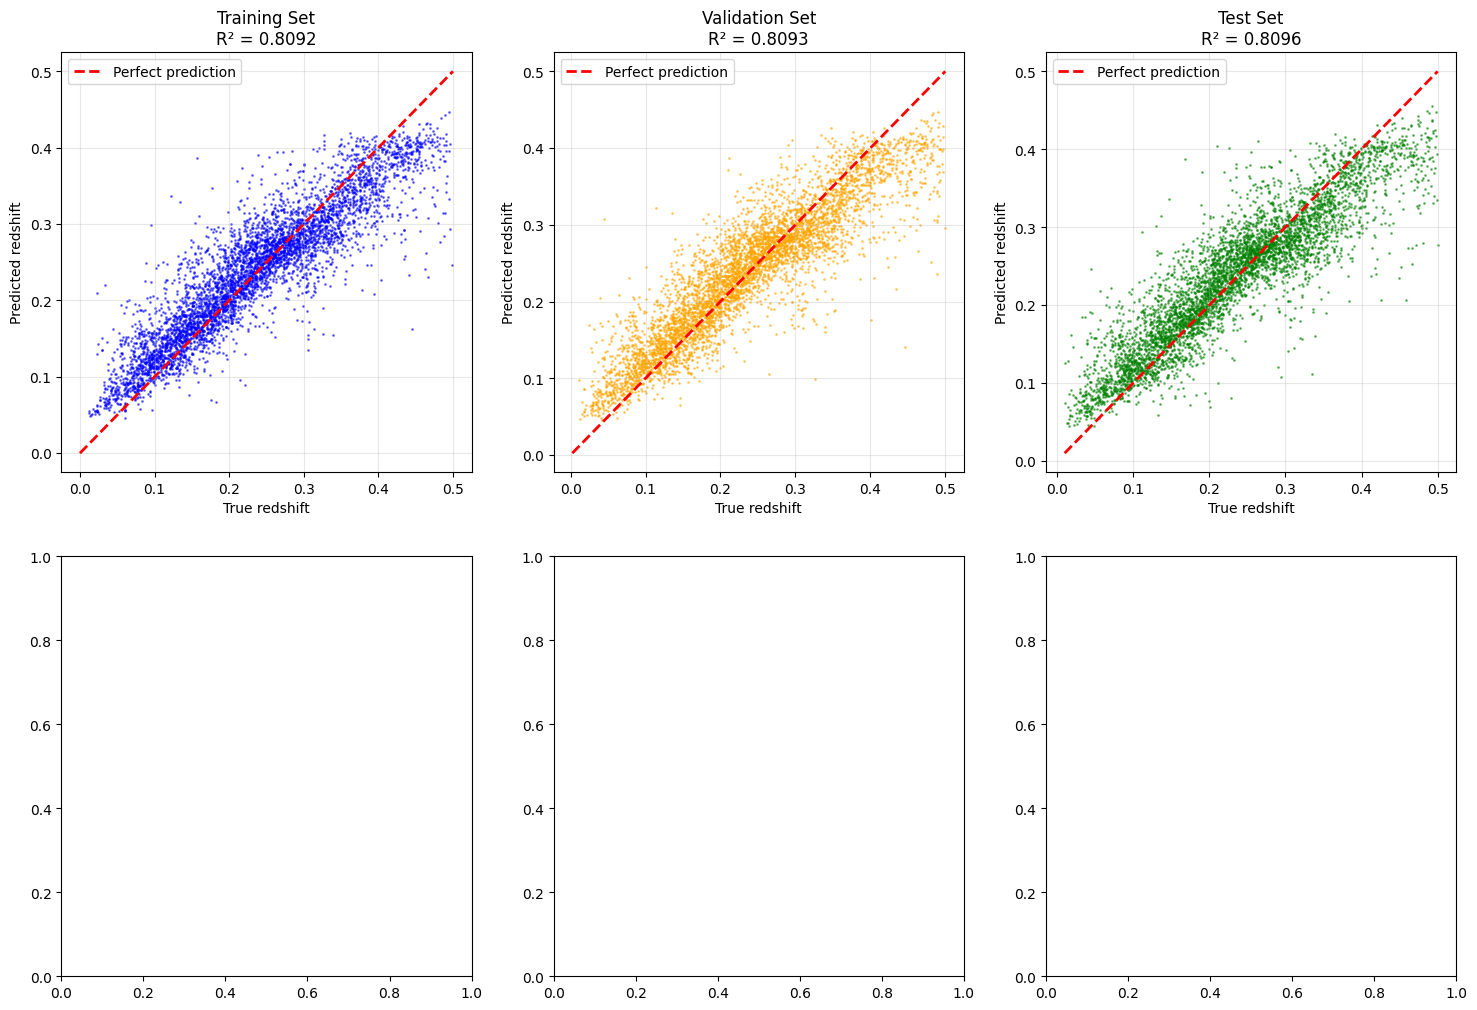

In [66]:
# Calculate predictions and metrics
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor).squeeze().cpu().numpy()
    y_pred_val = model(X_val_tensor).squeeze().cpu().numpy()
    y_pred_test = model(X_test_tensor).squeeze().cpu().numpy()

# Convert true values to numpy arrays
y_true_train = cv_pipe.y_train
y_true_val = cv_pipe.y_val
y_true_test = cv_pipe.y_test

# Calculate metrics for all splits
def calculate_metrics(y_true, y_pred, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{split_name} Metrics:")
    print(f"MAE: {mae:.6f}")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²: {r2:.6f}")
    
    return mae, mse, rmse, r2

# Calculate and print metrics for all splits
train_metrics = calculate_metrics(y_true_train, y_pred_train, "Training")
val_metrics = calculate_metrics(y_true_val, y_pred_val, "Validation")
test_metrics = calculate_metrics(y_true_test, y_pred_test, "Test")

# Create comprehensive plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Prediction vs True value plots
for i, (y_true, y_pred, title, color) in enumerate([
    (y_true_train, y_pred_train, "Training", "blue"),
    (y_true_val, y_pred_val, "Validation", "orange"),
    (y_true_test, y_pred_test, "Test", "green")
]):
    
    ax = axes[0, i]
    
    # Sample points for plotting (to avoid overcrowding)
    n_plot = min(5000, len(y_true))
    idx_plot = np.random.choice(len(y_true), n_plot, replace=False)
    
    ax.scatter(y_true[idx_plot], y_pred[idx_plot], alpha=0.5, s=1, color=color)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    ax.set_xlabel('True redshift')
    ax.set_ylabel('Predicted redshift')
    ax.set_title(f'{title} Set\nR² = {r2_score(y_true, y_pred):.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Residual plots
for i, (y_true, y_pred, title, color) in enumerate([
    (y_true_train, y_pred_train, "Training", "blue"),
    (y_true_val, y_pred_val, "Validation", "orange"),
    (y_true_test, y_pred_test, "Test", "green")
]):
    y_train_test, y_pred_test
    ax = axes[1, i]
    
    residuals = y_pred - y_true
    
    # Sample points for plotting
    n_plot = min(5000, len(y_true))
    idx_plot = np.random.choice(len(y_true), n_plot, replace=False)
    
    ax.scatter(y_true[idx_plot], residuals[idx_plot], alpha=0.5, s=1, color=color)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    
    ax.set_xlabel('True redshift')
    ax.set_ylabel('Residuals (Pred - True)')
    ax.set_title(f'{title} Residuals\nRMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("SUMMARY OF ALL METRICS")
print("="*60)
print(f"{'Metric':<12} {'Training':<12} {'Validation':<12} {'Test':<12}")
print("-"*60)
print(f"{'MAE':<12} {train_metrics[0]:<12.6f} {val_metrics[0]:<12.6f} {test_metrics[0]:<12.6f}")
print(f"{'MSE':<12} {train_metrics[1]:<12.6f} {val_metrics[1]:<12.6f} {test_metrics[1]:<12.6f}")
print(f"{'RMSE':<12} {train_metrics[2]:<12.6f} {val_metrics[2]:<12.6f} {test_metrics[2]:<12.6f}")
print(f"{'R²':<12} {train_metrics[3]:<12.6f} {val_metrics[3]:<12.6f} {test_metrics[3]:<12.6f}")
print("="*60)

In [ ]:
y_true_train, y_pred_train

In [67]:
test_photoz_metrics = PhotoZMetrics(y_true_train, y_pred_train)  # FIXED: true values first
val_photoz_metrics = PhotoZMetrics(y_true_val, y_pred_val)

In [68]:
print('Test summary',test_photoz_metrics.summary())
print('Validation summary',val_photoz_metrics.summary())

Test summary {'bias': np.float64(-0.0029464284422145662), 'sigma': np.float64(0.03711585481240694), 'sigma_NMAD': np.float64(0.03165719041901534), 'delta(0.3)': np.float64(0.9999771343535944), 'outlier_fraction(0.15)': np.float64(0.002147516790800347)}
Validation summary {'bias': np.float64(-0.0030106028067244635), 'sigma': np.float64(0.037108542879915066), 'sigma_NMAD': np.float64(0.031678535533218095), 'delta(0.3)': np.float64(0.9999888761788933), 'outlier_fraction(0.15)': np.float64(0.0022210562809728894)}


In [ ]:
np.min(X_train_scaled[:,1]), np.max(X_train_scaled[:,1])

In [ ]:
for i in range(X_train_scaled.shape[1]):
    print(f"Feature {i}: min={np.min(X_train_scaled[:,i])}, max={np.max(X_train_scaled[:,i])}")
#np.min(X_train_scaled[:,0]),np.max(X_train_scaled[:,0])

In [ ]:
for i in range(X_train_scaled.shape[1]):
    print(f"Feature {i}: min={np.min(X_train_scaled[:,i])}, max={np.max(X_train_scaled[:,i])}")
#np.min(X_train_scaled[:,0]),np.max(X_train_scaled[:,0])

In [ ]:
# Visualize how the fitted StandardScaler transformed the features
# (places this in a new notebook cell)

rng = np.random.default_rng(0)
n_samples = min(20000, X.shape[0])
idx = rng.choice(X.shape[0], size=n_samples, replace=False)

# Build numeric samples from object-typed X
X_sample = np.empty((n_samples, X.shape[1]), dtype=float)
for i in range(X.shape[1]):
    X_sample[:, i] = np.asarray(X[idx, i], dtype=float)

# Use the existing scaler to transform the same sample (consistent with training)
X_sample_scaled = scaler.transform(X_sample)

n_features = X_sample.shape[1]
fig, axes = plt.subplots(n_features, 2, figsize=(12, 3 * n_features))
if n_features == 1:
    axes = axes.reshape(1, 2)

for i in range(n_features):
    ax_orig = axes[i, 0]
    ax_scaled = axes[i, 1]

    ax_orig.hist(X_sample[:, i], bins=60, color='C0', alpha=0.6, density=True)
    ax_orig.set_title(f'Feature {i} original\nmean={X_sample[:,i].mean():.3f}, std={X_sample[:,i].std():.3f}')
    ax_orig.grid(alpha=0.3)

    ax_scaled.hist(X_sample_scaled[:, i], bins=60, color='C1', alpha=0.6, density=True)
    ax_scaled.set_title(f'Feature {i} scaled\nmean={X_sample_scaled[:,i].mean():.3f}, std={X_sample_scaled[:,i].std():.3f}')
    ax_scaled.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plots to show linear mapping for a couple of features
fig, axs = plt.subplots(1, min(2, n_features), figsize=(10, 4))
for j in range(min(2, n_features)):
    axs[j].scatter(X_sample[:, j], X_sample_scaled[:, j], s=1, alpha=0.5)
    axs[j].set_xlabel(f'orig f{j}')
    axs[j].set_ylabel(f'scaled f{j}')
    axs[j].set_title(f'Original vs Scaled (feature {j})')
    axs[j].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print scaler parameters for reference
print("scaler.mean_ =", np.round(scaler.mean_, 4))
print("scaler.scale_ =", np.round(scaler.scale_, 4))

In [74]:
[col for col in legacy.colnames if 'MAG' in col]

['GAIA_PHOT_G_MEAN_MAG',
 'MAG_G',
 'MAG_R',
 'MAG_Z',
 'MAG_W1',
 'MAG_W2',
 'MAG_W3',
 'MAG_GR',
 'MAG_RZ',
 'MAG_GZ',
 'MAG_W1W2',
 'MAG_W2W3',
 'MAG_W1W3',
 'MAG_RW1',
 'MAG_RW2',
 'MAG_RW3',
 'MAG_GW1',
 'MAG_GW2',
 'MAG_GW3',
 'MAG_ZW1',
 'MAG_ZW2',
 'MAG_ZW3']

In [75]:
legacy.colnames

['BRICKID',
 'BRICKNAME',
 'OBJID',
 'TYPE',
 'RA',
 'DEC',
 'FLUX_G',
 'FLUX_R',
 'FLUX_Z',
 'FLUX_W1',
 'FLUX_W2',
 'FLUX_W3',
 'FLUX_W4',
 'MW_TRANSMISSION_G',
 'MW_TRANSMISSION_R',
 'MW_TRANSMISSION_Z',
 'MW_TRANSMISSION_W1',
 'MW_TRANSMISSION_W2',
 'MW_TRANSMISSION_W3',
 'MW_TRANSMISSION_W4',
 'NOBS_G',
 'NOBS_R',
 'NOBS_Z',
 'FRACFLUX_G',
 'FRACFLUX_R',
 'FRACFLUX_Z',
 'FRACMASKED_G',
 'FRACMASKED_R',
 'FRACMASKED_Z',
 'FRACIN_G',
 'FRACIN_R',
 'FRACIN_Z',
 'PSFDEPTH_G',
 'PSFDEPTH_R',
 'PSFDEPTH_Z',
 'SHAPE_R',
 'SHAPE_E1',
 'SHAPE_E2',
 'FIBERFLUX_G',
 'FIBERFLUX_R',
 'FIBERFLUX_Z',
 'GAIA_PHOT_G_MEAN_MAG',
 'MASKBITS',
 'SERSIC',
 'Z_PHOT_MEAN',
 'Z_PHOT_MEDIAN',
 'Z_PHOT_L95',
 'Z_SPEC',
 'SURVEY',
 'MAG_G',
 'MAG_R',
 'MAG_Z',
 'MAG_W1',
 'MAG_W2',
 'MAG_W3',
 'MAG_GR',
 'MAG_RZ',
 'MAG_GZ',
 'MAG_W1W2',
 'MAG_W2W3',
 'MAG_W1W3',
 'MAG_RW1',
 'MAG_RW2',
 'MAG_RW3',
 'MAG_GW1',
 'MAG_GW2',
 'MAG_GW3',
 'MAG_ZW1',
 'MAG_ZW2',
 'MAG_ZW3']

In [76]:
len(legacy_filtered)

4315062